
**Project Title**
Estimating Unmet ADHD Assessment Demand in England Using Prevalence and Referral Data


**Aim**

To explore whether trends in ADHD prevalence, referrals and waiting-list activity can provide useful insight into where service pressure may be greatest and where potential unmet demand may exist within ADHD services in England.

**Objectives**

1. To examine trends in ADHD prevalence, waiting-list activity and referrals between December 2024 and December 2025 using NHS England ADHD data.

2. To compare patterns across age groups to identify differences in service demand and service pressure.

3. To explore the relationship between waiting-list activity and recorded ADHD prevalence as a proxy indicator of potential unmet demand.

4. To identify areas that may warrant further investigation for service planning, pathway development and future research.


---

**Data:**

NHS England - ADHD Taskforce. Available at: https://www.england.nhs.uk/mental-health/adhd/ 

NHS England  - Neurodevelopmental Data Hub. Available at: https://digital.nhs.uk/data-and-information/data-tools-and-services/data-services/neurodevelopmental-data-hub 

NHS England  - How to Correctly Submit Data on Autism and ADHD Assessments. Available at: https://digital.nhs.uk/data-and-information/data-tools-and-services/data-services/neurodevelopmental-data-hub/how-to-correctly-submit-data-on-autism-and-adhd-assessments 

NHS England  - ADHD Data Improvement Plan. Available at: https://digital.nhs.uk/data-and-information/data-tools-and-services/data-services/neurodevelopmental-data-hub/adhd-data-improvement-plan 

NHS England  - ADHD Management Information. Available at: https://digital.nhs.uk/data-and-information/publications/statistical/mi-adhd 

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ADHD MI dataset
adhd_df = pd.read_csv("ADHD_Feb26.csv")

# ONS population dataset
ons_df = pd.read_csv("pop.csv")

In [3]:
adhd_df.head(20)

,REPORTING_PERIOD_START_DATE,REPORTING_PERIOD_END_DATE,BREAKDOWN,PRIMARY_LEVEL,PRIMARY_LEVEL_DESCRIPTION,INDICATOR_ID,VALUE
0,01/11/2025,01/11/2025,Age Group,0 to 4,People aged 0 to 4,ADHD001,146000
1,01/11/2025,01/11/2025,Age Group,5 to 17,People aged 5 to 17,ADHD001,475000
2,01/11/2025,01/11/2025,Age Group,18 to 24,People aged 18 to 24,ADHD001,269000
3,01/11/2025,01/11/2025,Age Group,25+,People aged 25+,ADHD001,1616000
4,2025-02-01,2025-02-01,Age Group,0 to 4,People aged 0 to 4,ADHD001,148000
5,2025-02-01,2025-02-01,Age Group,5 to 17,People aged 5 to 17,ADHD001,477000
6,2025-02-01,2025-02-01,Age Group,18 to 24,People aged 18 to 24,ADHD001,265000
7,2025-02-01,2025-02-01,Age Group,25+,People aged 25+,ADHD001,1609000
8,2025-05-01,2025-05-01,Age Group,0 to 4,People aged 0 to 4,ADHD001,147000
9,2025-05-01,2025-05-01,Age Group,5 to 17,People aged 5 to 17,ADHD001,476000


In [4]:
ons_df.head(20)

,Title,Scotland population mid-year estimate,Great Britain population mid-year estimate,England population mid-year estimate,England and Wales population mid-year estimate,United Kingdom population mid-year estimate,Northern Ireland population mid-year estimate,Wales population mid-year estimate
0,CDID,SCPOP,GBPOP,ENPOP,EWPOP,UKPOP,NIPOP,WAPOP
1,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Release Date,27-11-2025,27-11-2025,27-11-2025,27-11-2025,27-11-2025,27-11-2025,27-11-2025
4,Next release,To be announced,To be announced,To be announced,To be announced,To be announced,To be announced,To be announced
5,Important Notes,NaN,[],NaN,NaN,[The UK estimate for mid-2025 is provisional a...,NaN,NaN
6,1971,5235600,54387600,46411700,49152000,55928000,1540400,2740300
7,1972,5230600,54557700,46571900,49327100,56096700,1539000,2755200
8,1973,5233900,54692900,46686200,49459000,56222900,1530000,2772800
9,1974,5240800,54708700,46682700,49467900,56235600,1526900,2785200


In [5]:
adhd_df.columns

Index(['REPORTING_PERIOD_START_DATE', 'REPORTING_PERIOD_END_DATE', 'BREAKDOWN',
       'PRIMARY_LEVEL', 'PRIMARY_LEVEL_DESCRIPTION', 'INDICATOR_ID', 'VALUE'],
      dtype='object')

In [6]:
ons_df.columns

Index(['Title', 'Scotland population mid-year estimate',
       'Great Britain population mid-year estimate',
       'England population mid-year estimate',
       'England and Wales population mid-year estimate',
       'United Kingdom population mid-year estimate',
       'Northern Ireland population mid-year estimate',
       'Wales population mid-year estimate'],
      dtype='object')

In [7]:
adhd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   REPORTING_PERIOD_START_DATE  8166 non-null   object
 1   REPORTING_PERIOD_END_DATE    8166 non-null   object
 2   BREAKDOWN                    8166 non-null   object
 3   PRIMARY_LEVEL                8166 non-null   object
 4   PRIMARY_LEVEL_DESCRIPTION    8166 non-null   object
 5   INDICATOR_ID                 8166 non-null   object
 6   VALUE                        8166 non-null   object
dtypes: object(7)
memory usage: 446.7+ KB


In [8]:
ons_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Title                                           61 non-null     object
 1   Scotland population mid-year estimate           57 non-null     object
 2   Great Britain population mid-year estimate      58 non-null     object
 3   England population mid-year estimate            57 non-null     object
 4   England and Wales population mid-year estimate  57 non-null     object
 5   United Kingdom population mid-year estimate     59 non-null     object
 6   Northern Ireland population mid-year estimate   57 non-null     object
 7   Wales population mid-year estimate              57 non-null     object
dtypes: object(8)
memory usage: 3.9+ KB


In [9]:
adhd_df.describe()

,REPORTING_PERIOD_START_DATE,REPORTING_PERIOD_END_DATE,BREAKDOWN,PRIMARY_LEVEL,PRIMARY_LEVEL_DESCRIPTION,INDICATOR_ID,VALUE
count,8166,8166,8166,8166,8166,8166,8166
unique,28,32,3,30,29,27,2521
top,2025-08-01,2025-08-31,Ethnicity,UNKNOWN,UNKNOWN,ADHD006,*
freq,628,624,5187,546,819,390,240


In [10]:
ons_df.describe()

,Title,Scotland population mid-year estimate,Great Britain population mid-year estimate,England population mid-year estimate,England and Wales population mid-year estimate,United Kingdom population mid-year estimate,Northern Ireland population mid-year estimate,Wales population mid-year estimate
count,61,57,58,57,57,59,57,57
unique,61,56,58,57,57,59,56,56
top,CDID,5083300,GBPOP,ENPOP,EWPOP,UKPOP,1523500,2804300
freq,1,2,1,1,1,1,2,2


In [11]:
adhd_df.shape

(8166, 7)

In [12]:
ons_df.shape

(61, 8)

---
## Initial Cleaning

In [13]:
#Remove extra spaces in column names
adhd_df.columns = adhd_df.columns.str.strip()
ons_df.columns = ons_df.columns.str.strip()

#Make column names easier to use
adhd_df.columns = adhd_df.columns.str.lower().str.replace(" ", "_")
ons_df.columns = ons_df.columns.str.lower().str.replace(" ", "_")


In [14]:
# Check time variables
adhd_df[['reporting_period_start_date', 'reporting_period_end_date']].head()

# Check ADHD geography / breakdown fields
print("Breakdowns:")
print(adhd_df['breakdown'].unique())

print("\nPrimary levels:")
print(adhd_df['primary_level'].unique())

# Check ONS column names
print("\nONS columns:")
print(ons_df.columns)

Breakdowns:
['Age Group' 'Ethnicity' 'Gender']

Primary levels:
['0 to 4' '5 to 17' '18 to 24' '25+' 'Unknown' 'R' 'L' 'P' 'UNKNOWN' 'J'
 'B' 'Not Stated' 'N' 'K' 'E' 'F' 'M' 'A' 'G' 'S' 'D' 'H' 'Not Known' 'C'
 '3' '2' '9' '4' '1' '5 to 24']

ONS columns:
Index(['title', 'scotland_population_mid-year_estimate',
       'great_britain_population_mid-year_estimate',
       'england_population_mid-year_estimate',
       'england_and_wales_population_mid-year_estimate',
       'united_kingdom_population_mid-year_estimate',
       'northern_ireland_population_mid-year_estimate',
       'wales_population_mid-year_estimate'],
      dtype='object')


#### Save a cleaned version

In [15]:
# Save a cleaned version
adhd_df.to_csv("adhd_cleaned.csv", index=False)
ons_df.to_csv("ons_cleaned.csv", index=False)

---
## Understanding the ADHD dataset

In [16]:
# Goal: Understand which indicators (What indicators exist?)
sorted(adhd_df['indicator_id'].unique())

['ADHD001',
 'ADHD003',
 'ADHD003a',
 'ADHD003b',
 'ADHD003c',
 'ADHD003d',
 'ADHD004',
 'ADHD004a',
 'ADHD004b',
 'ADHD004c',
 'ADHD004d',
 'ADHD005',
 'ADHD005a',
 'ADHD005b',
 'ADHD005c',
 'ADHD005d',
 'ADHD006',
 'ADHD006a',
 'ADHD006b',
 'ADHD006c',
 'ADHD006d',
 'ADHD007',
 'ADHD008',
 'ADHD008a',
 'ADHD008b',
 'ADHD008c',
 'ADHD008d']

In [17]:
# Goal: See how much data exists for each indicator. (How much data exists?)
adhd_df['indicator_id'].value_counts()

indicator_id
ADHD006     390
ADHD003c    390
ADHD004     390
ADHD004c    390
ADHD007     390
ADHD005     390
ADHD003     390
ADHD003b    388
ADHD004b    388
ADHD004d    387
ADHD003a    387
ADHD003d    387
ADHD004a    387
ADHD006c    383
ADHD006a    378
ADHD006b    377
ADHD005b    377
ADHD005d    377
ADHD005c    377
ADHD005a    377
ADHD006d    377
ADHD001      24
ADHD008      13
ADHD008a     13
ADHD008b     13
ADHD008c     13
ADHD008d     13
Name: count, dtype: int64

In [18]:
# Goal: Start understanding what the values represent. (What do the values look like?)
adhd_df[['indicator_id', 'value']].head(20)

,indicator_id,value
0,ADHD001,146000
1,ADHD001,475000
2,ADHD001,269000
3,ADHD001,1616000
4,ADHD001,148000
5,ADHD001,477000
6,ADHD001,265000
7,ADHD001,1609000
8,ADHD001,147000
9,ADHD001,476000


In [19]:
adhd_df.head(20)

,reporting_period_start_date,reporting_period_end_date,breakdown,primary_level,primary_level_description,indicator_id,value
0,01/11/2025,01/11/2025,Age Group,0 to 4,People aged 0 to 4,ADHD001,146000
1,01/11/2025,01/11/2025,Age Group,5 to 17,People aged 5 to 17,ADHD001,475000
2,01/11/2025,01/11/2025,Age Group,18 to 24,People aged 18 to 24,ADHD001,269000
3,01/11/2025,01/11/2025,Age Group,25+,People aged 25+,ADHD001,1616000
4,2025-02-01,2025-02-01,Age Group,0 to 4,People aged 0 to 4,ADHD001,148000
5,2025-02-01,2025-02-01,Age Group,5 to 17,People aged 5 to 17,ADHD001,477000
6,2025-02-01,2025-02-01,Age Group,18 to 24,People aged 18 to 24,ADHD001,265000
7,2025-02-01,2025-02-01,Age Group,25+,People aged 25+,ADHD001,1609000
8,2025-05-01,2025-05-01,Age Group,0 to 4,People aged 0 to 4,ADHD001,147000
9,2025-05-01,2025-05-01,Age Group,5 to 17,People aged 5 to 17,ADHD001,476000


In [20]:
# Goal: Confirm whether you have England-only data or regional data. (What geography level is available?)
adhd_df['primary_level_description'].unique()
sorted(adhd_df['indicator_id'].unique())

['ADHD001',
 'ADHD003',
 'ADHD003a',
 'ADHD003b',
 'ADHD003c',
 'ADHD003d',
 'ADHD004',
 'ADHD004a',
 'ADHD004b',
 'ADHD004c',
 'ADHD004d',
 'ADHD005',
 'ADHD005a',
 'ADHD005b',
 'ADHD005c',
 'ADHD005d',
 'ADHD006',
 'ADHD006a',
 'ADHD006b',
 'ADHD006c',
 'ADHD006d',
 'ADHD007',
 'ADHD008',
 'ADHD008a',
 'ADHD008b',
 'ADHD008c',
 'ADHD008d']

In [21]:
#tell us how much data exists for each measure.
adhd_df['indicator_id'].value_counts()

indicator_id
ADHD006     390
ADHD003c    390
ADHD004     390
ADHD004c    390
ADHD007     390
ADHD005     390
ADHD003     390
ADHD003b    388
ADHD004b    388
ADHD004d    387
ADHD003a    387
ADHD003d    387
ADHD004a    387
ADHD006c    383
ADHD006a    378
ADHD006b    377
ADHD005b    377
ADHD005d    377
ADHD005c    377
ADHD005a    377
ADHD006d    377
ADHD001      24
ADHD008      13
ADHD008a     13
ADHD008b     13
ADHD008c     13
ADHD008d     13
Name: count, dtype: int64

---
## My notes:

- ADHD001 appears to represent estimated ADHD prevalence.
- The data is broken down by age group (0–4, 5–17, 18–24 and 25+).
- Values appear relatively stable across reporting periods and likely represent estimated numbers of people with ADHD rather than service activity.



- The dataset contains multiple ADHD indicators (ADHD001–ADHD008 and subcategories).
- These appear to represent different aspects of ADHD prevalence, referrals, waiting lists and pathway activity.
- Further work is needed to identify which indicators are most relevant to the research question.



---
## Clean datasets

In [22]:
# Convert dates
adhd_df['reporting_period_start_date'] = pd.to_datetime(
    adhd_df['reporting_period_start_date'],
    errors='coerce'
)
adhd_df['year'] = adhd_df['reporting_period_start_date'].dt.year
adhd_df[['reporting_period_start_date','year']].head()

,reporting_period_start_date,year
0,2025-01-11,2025.0
1,2025-01-11,2025.0
2,2025-01-11,2025.0
3,2025-01-11,2025.0
4,NaT,NaN


In [23]:
adhd_df['reporting_period_start_date'].head(20)

0    2025-01-11
1    2025-01-11
2    2025-01-11
3    2025-01-11
4           NaT
5           NaT
6           NaT
7           NaT
8           NaT
9           NaT
10          NaT
11          NaT
12          NaT
13          NaT
14          NaT
15          NaT
16          NaT
17          NaT
18          NaT
19          NaT
Name: reporting_period_start_date, dtype: datetime64[ns]

In [24]:
adhd_df = pd.read_csv("ADHD_Feb26.csv")
adhd_df.columns = adhd_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [25]:
# Convert date columns safely where formats may be mixed
adhd_df['reporting_period_start_date'] = pd.to_datetime(
    adhd_df['reporting_period_start_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

adhd_df['reporting_period_end_date'] = pd.to_datetime(
    adhd_df['reporting_period_end_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Create year column
adhd_df['year'] = adhd_df['reporting_period_start_date'].dt.year

In [26]:
adhd_df[['reporting_period_start_date', 'year']].head(20)

,reporting_period_start_date,year
0,2025-11-01,2025
1,2025-11-01,2025
2,2025-11-01,2025
3,2025-11-01,2025
4,2025-02-01,2025
5,2025-02-01,2025
6,2025-02-01,2025
7,2025-02-01,2025
8,2025-05-01,2025
9,2025-05-01,2025


In [27]:
adhd_df['reporting_period_start_date'].isna().sum()

np.int64(0)

In [28]:
# Identify which indicators are useful for capstone
adhd_df['indicator_id'].value_counts()

indicator_id
ADHD006     390
ADHD003c    390
ADHD004     390
ADHD004c    390
ADHD007     390
ADHD005     390
ADHD003     390
ADHD003b    388
ADHD004b    388
ADHD004d    387
ADHD003a    387
ADHD003d    387
ADHD004a    387
ADHD006c    383
ADHD006a    378
ADHD006b    377
ADHD005b    377
ADHD005d    377
ADHD005c    377
ADHD005a    377
ADHD006d    377
ADHD001      24
ADHD008      13
ADHD008a     13
ADHD008b     13
ADHD008c     13
ADHD008d     13
Name: count, dtype: int64

In [29]:
adhd_df[adhd_df['indicator_id'] == 'ADHD003'].head(20)

,reporting_period_start_date,reporting_period_end_date,breakdown,primary_level,primary_level_description,indicator_id,value,year
24,2024-12-01,2024-12-31,Age Group,25+,People aged 25+,ADHD003,157390,2024
25,2024-12-01,2024-12-31,Age Group,0 to 4,People aged 0 to 4,ADHD003,2055,2024
26,2024-12-01,2024-12-31,Age Group,5 to 17,People aged 5 to 17,ADHD003,140365,2024
27,2024-12-01,2024-12-31,Age Group,Unknown,People aged Unknown,ADHD003,*,2024
28,2024-12-01,2024-12-31,Age Group,18 to 24,People aged 18 to 24,ADHD003,65780,2024
29,2025-01-01,2025-01-31,Age Group,Unknown,People aged Unknown,ADHD003,*,2025
30,2025-01-01,2025-01-31,Age Group,0 to 4,People aged 0 to 4,ADHD003,2045,2025
31,2025-01-01,2025-01-31,Age Group,18 to 24,People aged 18 to 24,ADHD003,65770,2025
32,2025-01-01,2025-01-31,Age Group,5 to 17,People aged 5 to 17,ADHD003,142485,2025
33,2025-01-01,2025-01-31,Age Group,25+,People aged 25+,ADHD003,158240,2025


In [30]:
adhd_df[adhd_df['indicator_id'] == 'ADHD004'].head(20)

,reporting_period_start_date,reporting_period_end_date,breakdown,primary_level,primary_level_description,indicator_id,value,year
341,2024-12-01,2024-12-31,Age Group,Unknown,People aged Unknown,ADHD004,*,2024
342,2024-12-01,2024-12-31,Age Group,25+,People aged 25+,ADHD004,127850,2024
343,2024-12-01,2024-12-31,Age Group,18 to 24,People aged 18 to 24,ADHD004,51560,2024
344,2024-12-01,2024-12-31,Age Group,5 to 17,People aged 5 to 17,ADHD004,77825,2024
345,2024-12-01,2024-12-31,Age Group,0 to 4,People aged 0 to 4,ADHD004,1210,2024
346,2025-01-01,2025-01-31,Age Group,5 to 17,People aged 5 to 17,ADHD004,78380,2025
347,2025-01-01,2025-01-31,Age Group,0 to 4,People aged 0 to 4,ADHD004,1190,2025
348,2025-01-01,2025-01-31,Age Group,Unknown,People aged Unknown,ADHD004,*,2025
349,2025-01-01,2025-01-31,Age Group,25+,People aged 25+,ADHD004,128125,2025
350,2025-01-01,2025-01-31,Age Group,18 to 24,People aged 18 to 24,ADHD004,51185,2025


In [31]:
adhd_df[adhd_df['indicator_id'] == 'ADHD005'].head(20)

,reporting_period_start_date,reporting_period_end_date,breakdown,primary_level,primary_level_description,indicator_id,value,year
658,2024-12-01,2024-12-31,Age Group,5 to 17,People aged 5 to 17,ADHD005,62540,2024
659,2024-12-01,2024-12-31,Age Group,25+,People aged 25+,ADHD005,29540,2024
660,2024-12-01,2024-12-31,Age Group,18 to 24,People aged 18 to 24,ADHD005,14220,2024
661,2024-12-01,2024-12-31,Age Group,Unknown,People aged Unknown,ADHD005,*,2024
662,2024-12-01,2024-12-31,Age Group,0 to 4,People aged 0 to 4,ADHD005,845,2024
663,2025-01-01,2025-01-31,Age Group,18 to 24,People aged 18 to 24,ADHD005,14585,2025
664,2025-01-01,2025-01-31,Age Group,5 to 17,People aged 5 to 17,ADHD005,64110,2025
665,2025-01-01,2025-01-31,Age Group,25+,People aged 25+,ADHD005,30115,2025
666,2025-01-01,2025-01-31,Age Group,0 to 4,People aged 0 to 4,ADHD005,855,2025
667,2025-01-01,2025-01-31,Age Group,Unknown,People aged Unknown,ADHD005,*,2025


In [32]:
adhd_df[adhd_df['indicator_id']=='ADHD003'].sample(10)
adhd_df.columns

Index(['reporting_period_start_date', 'reporting_period_end_date', 'breakdown',
       'primary_level', 'primary_level_description', 'indicator_id', 'value',
       'year'],
      dtype='object')

In [33]:
for indicator in ['ADHD001','ADHD003','ADHD004','ADHD005','ADHD006']:
    print("\n", indicator)
    print(
        adhd_df[
            adhd_df['indicator_id']==indicator
        ][['breakdown']].drop_duplicates()
    )


 ADHD001
   breakdown
0  Age Group

 ADHD003
      breakdown
24    Age Group
1279  Ethnicity
6466     Gender

 ADHD004
      breakdown
341   Age Group
2514  Ethnicity
6856     Gender

 ADHD005
      breakdown
658   Age Group
3749  Ethnicity
7246     Gender

 ADHD006
      breakdown
931   Age Group
4984  Ethnicity
7636     Gender


In [34]:
adhd_df[adhd_df['indicator_id'] == 'ADHD006'].head(20)

,reporting_period_start_date,reporting_period_end_date,breakdown,primary_level,primary_level_description,indicator_id,value,year
931,2024-12-01,2024-12-31,Age Group,Unknown,People aged Unknown,ADHD006,*,2024
932,2024-12-01,2024-12-31,Age Group,18 to 24,People aged 18 to 24,ADHD006,1880,2024
933,2024-12-01,2024-12-31,Age Group,25+,People aged 25+,ADHD006,3850,2024
934,2024-12-01,2024-12-31,Age Group,5 to 17,People aged 5 to 17,ADHD006,5575,2024
935,2024-12-01,2024-12-31,Age Group,0 to 4,People aged 0 to 4,ADHD006,155,2024
936,2025-01-01,2025-01-31,Age Group,18 to 24,People aged 18 to 24,ADHD006,2280,2025
937,2025-01-01,2025-01-31,Age Group,0 to 4,People aged 0 to 4,ADHD006,200,2025
938,2025-01-01,2025-01-31,Age Group,Unknown,People aged Unknown,ADHD006,*,2025
939,2025-01-01,2025-01-31,Age Group,5 to 17,People aged 5 to 17,ADHD006,6310,2025
940,2025-01-01,2025-01-31,Age Group,25+,People aged 25+,ADHD006,4825,2025


In [35]:
# Create a numeric version of VALUE

adhd_df['value_numeric'] = pd.to_numeric(
    adhd_df['value'],
    errors='coerce'
)

adhd_df[['value', 'value_numeric']].head(20)

,value,value_numeric
0,146000,146000.0
1,475000,475000.0
2,269000,269000.0
3,1616000,1616000.0
4,148000,148000.0
5,477000,477000.0
6,265000,265000.0
7,1609000,1609000.0
8,147000,147000.0
9,476000,476000.0


In [36]:
# Check how many suppressed values exist

adhd_df['value_numeric'].isna().sum()

np.int64(240)

---
## My notes: Data quality

The ADHD dataset contains 240 suppressed values ("*"), which were converted to missing values (NaN) using pd.to_numeric(errors='coerce').

In [37]:
# How many records do we have for each indicator?
adhd_df.groupby('indicator_id')['value_numeric'].count().sort_values(ascending=False)

indicator_id
ADHD004     388
ADHD003     388
ADHD003b    384
ADHD004b    384
ADHD003a    380
ADHD004d    379
ADHD003c    379
ADHD003d    379
ADHD004a    379
ADHD004c    379
ADHD005a    377
ADHD005b    377
ADHD005     377
ADHD006     374
ADHD005d    373
ADHD007     371
ADHD005c    368
ADHD006d    358
ADHD006b    352
ADHD006c    346
ADHD006a    345
ADHD001      24
ADHD008      13
ADHD008a     13
ADHD008b     13
ADHD008c     13
ADHD008d     13
Name: value_numeric, dtype: int64

In [38]:
#discover what the indicators actually mean
adhd_df[
    adhd_df['indicator_id'].isin(
        ['ADHD001','ADHD003','ADHD004','ADHD005','ADHD006']
    )
][['indicator_id','primary_level_description','value_numeric']].sample(20)

,indicator_id,primary_level_description,value_numeric
343,ADHD004,People aged 18 to 24,51560.0
5148,ADHD006,Caribbean,145.0
1285,ADHD003,Not stated,43600.0
5064,ADHD006,UNKNOWN,1825.0
7247,ADHD005,UNKNOWN,130.0
2558,ADHD004,Any other Asian background,2365.0
2535,ADHD004,Any other mixed background,5845.0
1284,ADHD003,Irish,1410.0
3845,ADHD005,White and Asian,840.0
2526,ADHD004,Caribbean,1760.0


In [39]:
#total volume for each indicator
adhd_df.groupby('indicator_id')['value_numeric'].sum().sort_values(ascending=False)

indicator_id
ADHD003     19158815.0
ADHD001     15002000.0
ADHD004     14289240.0
ADHD003d     6219600.0
ADHD003c     5699025.0
ADHD003b     5166825.0
ADHD005      4869545.0
ADHD004c     4534870.0
ADHD004b     4026155.0
ADHD004d     3879320.0
ADHD008      2197176.0
ADHD003a     2073340.0
ADHD005a     2029620.0
ADHD004a     1848750.0
ADHD005b     1682675.0
ADHD008b      925172.0
ADHD007       809860.0
ADHD006       694220.0
ADHD005c      631800.0
ADHD008c      580315.0
ADHD005d      525450.0
ADHD008a      451622.0
ADHD008d      239716.0
ADHD006a      226775.0
ADHD006b      178155.0
ADHD006d      167065.0
ADHD006c      122025.0
Name: value_numeric, dtype: float64

---
## Initial exploration findings

- Dataset contains 8,166 records.
- Dates have been cleaned and converted to datetime format.
- A numeric version of the value field was created.
- 240 suppressed values (*) were converted to missing values (NaN).
- The dataset contains multiple indicators (ADHD001–ADHD008).
- Indicators ADHD003–ADHD006 contain the largest number of records and appear most relevant for pathway analysis.
- Further work is required to confirm the definition of each indicator before building the final analysis dataset.

---
## Understanding the ADHD Indicators

Before starting the analysis, I reviewed the NHS ADHD data dictionary to understand what each indicator represents.

The main indicators selected for this project are:

- ADHD001 – estimated ADHD prevalence (expected need)
- ADHD007 – new referrals received (new demand)
- ADHD003 – open referrals (current waiting list)
- ADHD004 – open referrals with no first contact (waiting to enter services)
- ADHD006 – closed referrals (throughput)

Together, these indicators provide a high-level view of ADHD demand, waiting lists and service activity. Additional indicators provide further breakdowns by waiting time, ethnicity, gender and age group.

---
## Creating the Analysis Dataset

For the initial analysis, only the indicators most relevant to ADHD demand and waiting lists were selected:

- ADHD001 – Estimated ADHD prevalence
- ADHD003 – Open referrals
- ADHD004 – Open referrals with no first contact
- ADHD006 – Closed referrals
- ADHD007 – New referrals

This reduces the dataset size and focuses the analysis on demand, waiting lists and service activity.

In [40]:
# Keep only indicators needed for the capstone

analysis_df = adhd_df[
    adhd_df['indicator_id'].isin(
        ['ADHD001', 'ADHD003', 'ADHD004', 'ADHD006', 'ADHD007']
    )
].copy()

analysis_df.shape

(1584, 9)

In [41]:
#Create a smaller working dataset
analysis_df['indicator_id'].value_counts()

indicator_id
ADHD003    390
ADHD004    390
ADHD006    390
ADHD007    390
ADHD001     24
Name: count, dtype: int64

In [42]:
# Keep only age group breakdowns for the first analysis

analysis_age_df = analysis_df[
    analysis_df['breakdown'] == 'Age Group'
].copy()

analysis_age_df.shape

(284, 9)

In [43]:
analysis_age_df['indicator_id'].value_counts()

indicator_id
ADHD003    65
ADHD004    65
ADHD006    65
ADHD007    65
ADHD001    24
Name: count, dtype: int64

In [44]:
analysis_age_df[
    analysis_age_df['indicator_id'] == 'ADHD007'
].head(20)

,reporting_period_start_date,reporting_period_end_date,breakdown,primary_level,primary_level_description,indicator_id,value,year,value_numeric
1214,2024-12-01,2024-12-31,Age Group,0 to 4,People aged 0 to 4,ADHD007,160,2024,160.0
1215,2024-12-01,2024-12-31,Age Group,25+,People aged 25+,ADHD007,5945,2024,5945.0
1216,2024-12-01,2024-12-31,Age Group,Unknown,People aged Unknown,ADHD007,*,2024,NaN
1217,2024-12-01,2024-12-31,Age Group,18 to 24,People aged 18 to 24,ADHD007,2425,2024,2425.0
1218,2024-12-01,2024-12-31,Age Group,5 to 17,People aged 5 to 17,ADHD007,7595,2024,7595.0
1219,2025-01-01,2025-01-31,Age Group,18 to 24,People aged 18 to 24,ADHD007,2575,2025,2575.0
1220,2025-01-01,2025-01-31,Age Group,0 to 4,People aged 0 to 4,ADHD007,175,2025,175.0
1221,2025-01-01,2025-01-31,Age Group,5 to 17,People aged 5 to 17,ADHD007,8500,2025,8500.0
1222,2025-01-01,2025-01-31,Age Group,25+,People aged 25+,ADHD007,6225,2025,6225.0
1223,2025-01-01,2025-01-31,Age Group,Unknown,People aged Unknown,ADHD007,*,2025,NaN


---
## My notes: Initial observation
Referral volumes appear high (~20,000+ per month across age groups).
Need to confirm:
- geography level (likely England)
- exact definition of ADHD007 before interpreting trends. ("New referrals received", "People entering assessment pathway", or "Open referrals".

In [45]:
# What reporting months do we have?

analysis_age_df['reporting_period_start_date'].sort_values().unique()

<DatetimeArray>
['2024-12-01 00:00:00', '2025-01-01 00:00:00', '2025-02-01 00:00:00',
 '2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-08-01 00:00:00',
 '2025-09-01 00:00:00', '2025-10-01 00:00:00', '2025-11-01 00:00:00',
 '2025-12-01 00:00:00', '2026-01-01 00:00:00', '2026-02-01 00:00:00']
Length: 15, dtype: datetime64[ns]

---
## ✎ Time Coverage

The analysis dataset contains monthly ADHD activity data from December 2024 to February 2026 (15 reporting periods). This provides sufficient time coverage to explore trends in prevalence, referrals, waiting lists and service demand over time.

In [46]:
# Validation cell
analysis_age_df['primary_level'].value_counts()


# What output tells us:
#4 meaningful age groups +
#1 Unknown category +
# 15 months +
# 4 key indicators

primary_level
0 to 4      58
5 to 17     58
18 to 24    58
25+         58
Unknown     52
Name: count, dtype: int64

In [47]:
# Remove Unknown age group

analysis_age_df = analysis_age_df[
    analysis_age_df['primary_level'] != 'Unknown'
].copy()

analysis_age_df['primary_level'].value_counts()

primary_level
0 to 4      58
5 to 17     58
18 to 24    58
25+         58
Name: count, dtype: int64

In [48]:
# Reshape dataset so indicators become columns

pivot_df = analysis_age_df.pivot_table(
    index=['reporting_period_start_date', 'primary_level'],
    columns='indicator_id',
    values='value_numeric'
).reset_index()

pivot_df.head()

indicator_id,reporting_period_start_date,primary_level,ADHD001,ADHD003,ADHD004,ADHD006,ADHD007
0,2024-12-01,0 to 4,NaN,2055.0,1210.0,155.0,160.0
1,2024-12-01,18 to 24,NaN,65780.0,51560.0,1880.0,2425.0
2,2024-12-01,25+,NaN,157390.0,127850.0,3850.0,5945.0
3,2024-12-01,5 to 17,NaN,140365.0,77825.0,5575.0,7595.0
4,2025-01-01,0 to 4,NaN,2045.0,1190.0,200.0,175.0


In [49]:
#Remove ADHD001 --> because only exists by age group and quarter, not monthly.

pivot_df = pivot_df.drop(columns=['ADHD001'])

pivot_df.head()

indicator_id,reporting_period_start_date,primary_level,ADHD003,ADHD004,ADHD006,ADHD007
0,2024-12-01,0 to 4,2055.0,1210.0,155.0,160.0
1,2024-12-01,18 to 24,65780.0,51560.0,1880.0,2425.0
2,2024-12-01,25+,157390.0,127850.0,3850.0,5945.0
3,2024-12-01,5 to 17,140365.0,77825.0,5575.0,7595.0
4,2025-01-01,0 to 4,2045.0,1190.0,200.0,175.0


In [50]:
# Validation cell
pivot_df.shape

# Output of this cell: Maths chekcs out! 15 months × 4 age groups = 60 rows


(60, 6)

In [51]:
# Rename indicators to meaningful names

pivot_df = pivot_df.rename(columns={
    'ADHD003': 'prevalence',
    'ADHD004': 'waiting_list',
    'ADHD006': 'open_referrals',
    'ADHD007': 'new_referrals'
})

pivot_df.head()

indicator_id,reporting_period_start_date,primary_level,prevalence,waiting_list,open_referrals,new_referrals
0,2024-12-01,0 to 4,2055.0,1210.0,155.0,160.0
1,2024-12-01,18 to 24,65780.0,51560.0,1880.0,2425.0
2,2024-12-01,25+,157390.0,127850.0,3850.0,5945.0
3,2024-12-01,5 to 17,140365.0,77825.0,5575.0,7595.0
4,2025-01-01,0 to 4,2045.0,1190.0,200.0,175.0


## ✎ Indicator Names

To improve readability, the NHS indicator codes were renamed:

- ADHD003 = Prevalence
- ADHD004 = Waiting List
- ADHD006 = Open Referrals
- ADHD007 = New Referrals

This makes subsequent analysis and visualisations easier to interpret.

In [52]:
# Monthly totals across all age groups

monthly_df = (
    pivot_df
    .groupby('reporting_period_start_date')
    [['prevalence',
      'waiting_list',
      'open_referrals',
      'new_referrals']]
    .sum()
)

monthly_df.head()

indicator_id,prevalence,waiting_list,open_referrals,new_referrals
reporting_period_start_date,,,,
2024-12-01,365590.0,258445.0,11460.0,16125.0
2025-01-01,368540.0,258880.0,13615.0,17475.0
2025-02-01,451660.0,339465.0,15740.0,17695.0
2025-03-01,467765.0,354180.0,19725.0,25005.0
2025-04-01,491505.0,376875.0,16490.0,21765.0


In [53]:
# Check full monthly dataset

monthly_df

indicator_id,prevalence,waiting_list,open_referrals,new_referrals
reporting_period_start_date,,,,
2024-12-01,365590.0,258445.0,11460.0,16125.0
2025-01-01,368540.0,258880.0,13615.0,17475.0
2025-02-01,451660.0,339465.0,15740.0,17695.0
2025-03-01,467765.0,354180.0,19725.0,25005.0
2025-04-01,491505.0,376875.0,16490.0,21765.0
2025-05-01,504835.0,386995.0,16525.0,22110.0
2025-06-01,514290.0,393025.0,17065.0,23350.0
2025-07-01,524315.0,403245.0,20950.0,25245.0
2025-08-01,527715.0,403155.0,16865.0,19080.0


In [54]:
pivot_df[
    pivot_df['reporting_period_start_date'] >= '2026-01-01'
]

indicator_id,reporting_period_start_date,primary_level,prevalence,waiting_list,open_referrals,new_referrals
52,2026-01-01,0 to 4,NaN,NaN,NaN,NaN
53,2026-01-01,18 to 24,NaN,NaN,NaN,NaN
54,2026-01-01,25+,NaN,NaN,NaN,NaN
55,2026-01-01,5 to 17,NaN,NaN,NaN,NaN
56,2026-02-01,0 to 4,NaN,NaN,NaN,NaN
57,2026-02-01,18 to 24,NaN,NaN,NaN,NaN
58,2026-02-01,25+,NaN,NaN,NaN,NaN
59,2026-02-01,5 to 17,NaN,NaN,NaN,NaN


In [55]:
# Remove months with no published data

pivot_df = pivot_df[
    pivot_df['reporting_period_start_date'] < '2026-01-01'
].copy()

pivot_df.shape

(52, 6)

---
## ✎ Data completeness

- The Jan 2026 and Feb 2026 reporting periods contain no published values for the selected indicators. These records were excluded from the anlysis to avoid misleading results and ernsure all trend analysis was based on complete monthly data.

**So final analysis period is:**

- December 2024
- January 2025
- February 2025
- March 2025
- April 2025
- May 2025
- June 2025
- July 2025
- August 2025
- September 2025
- October 2025
- November 2025
- December 2025

In [56]:
pivot_df['reporting_period_start_date'].unique()

<DatetimeArray>
['2024-12-01 00:00:00', '2025-01-01 00:00:00', '2025-02-01 00:00:00',
 '2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-08-01 00:00:00',
 '2025-09-01 00:00:00', '2025-10-01 00:00:00', '2025-11-01 00:00:00',
 '2025-12-01 00:00:00']
Length: 13, dtype: datetime64[ns]

---
# ✎ Exploratory Data Analysis (EDA)

The cleaned dataset was explored to understand trends in ADHD prevalence, waiting lists, open referrals and new referrals over time. The analysis starts by looking at monthly totals across all age groups before exploring differences between age groups.

In [57]:
monthly_df

indicator_id,prevalence,waiting_list,open_referrals,new_referrals
reporting_period_start_date,,,,
2024-12-01,365590.0,258445.0,11460.0,16125.0
2025-01-01,368540.0,258880.0,13615.0,17475.0
2025-02-01,451660.0,339465.0,15740.0,17695.0
2025-03-01,467765.0,354180.0,19725.0,25005.0
2025-04-01,491505.0,376875.0,16490.0,21765.0
2025-05-01,504835.0,386995.0,16525.0,22110.0
2025-06-01,514290.0,393025.0,17065.0,23350.0
2025-07-01,524315.0,403245.0,20950.0,25245.0
2025-08-01,527715.0,403155.0,16865.0,19080.0


In [58]:
# Recreate monthly totals using the cleaned dataset

monthly_df = (
    pivot_df
    .groupby('reporting_period_start_date')
    [['prevalence',
      'waiting_list',
      'open_referrals',
      'new_referrals']]
    .sum()
)

monthly_df

indicator_id,prevalence,waiting_list,open_referrals,new_referrals
reporting_period_start_date,,,,
2024-12-01,365590.0,258445.0,11460.0,16125.0
2025-01-01,368540.0,258880.0,13615.0,17475.0
2025-02-01,451660.0,339465.0,15740.0,17695.0
2025-03-01,467765.0,354180.0,19725.0,25005.0
2025-04-01,491505.0,376875.0,16490.0,21765.0
2025-05-01,504835.0,386995.0,16525.0,22110.0
2025-06-01,514290.0,393025.0,17065.0,23350.0
2025-07-01,524315.0,403245.0,20950.0,25245.0
2025-08-01,527715.0,403155.0,16865.0,19080.0


---
## My notes:

**Eyeballing the table:**
- prevalence appears to be rising steadily
- waiting lists appear to be rising steadily
- referrals are more volatile month-to-month
- waiting list growth seems faster than referral growth

In [59]:
# Rebuild monthly totals using the cleaned dataset

monthly_df = (
    pivot_df
    .groupby('reporting_period_start_date')[
        ['prevalence',
         'waiting_list',
         'open_referrals',
         'new_referrals']
    ]
    .sum()
)

monthly_df

indicator_id,prevalence,waiting_list,open_referrals,new_referrals
reporting_period_start_date,,,,
2024-12-01,365590.0,258445.0,11460.0,16125.0
2025-01-01,368540.0,258880.0,13615.0,17475.0
2025-02-01,451660.0,339465.0,15740.0,17695.0
2025-03-01,467765.0,354180.0,19725.0,25005.0
2025-04-01,491505.0,376875.0,16490.0,21765.0
2025-05-01,504835.0,386995.0,16525.0,22110.0
2025-06-01,514290.0,393025.0,17065.0,23350.0
2025-07-01,524315.0,403245.0,20950.0,25245.0
2025-08-01,527715.0,403155.0,16865.0,19080.0


In [60]:
# Validation cell --> Check dimensions of monthly dataset

monthly_df.shape

(13, 4)

---
# ✎ Note: Monthly Dataset

The monthly dataset contains 13 complete reporting periods from December 2024 to December 2025. Values represent totals across all age groups for prevalence, waiting lists, open referrals and new referrals. This dataset will be used to explore overall trends in ADHD service demand over time.

## My notes: 

### Creating charts

| Metric         | Colour                   |
| -------------- | ------------------------ |
| Prevalence     | `#AE2573` NHS Pink       |
| Waiting List   | `#330072` NHS Purple     |
| Open Referrals | `#7C2855` NHS Dark Pink  |
| New Referrals  | `#78BE20` NHS Light Green|


| Age group | Suggested colour |
| --------- | ---------------- |
| 0 to 4    | `#768692`        |
| 5 to 17   | `#0072CE`        |
| 18 to 24  | `#00A499`        |
| 25+       | `#003087`        |


Note: https://www.england.nhs.uk/nhsidentity/identity-guidelines/colours/ 

In [61]:
import os

os.makedirs("images", exist_ok=True)

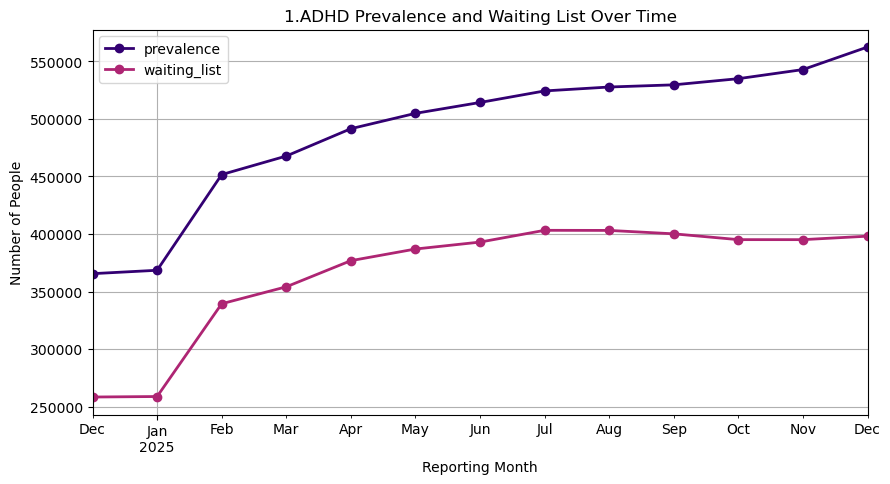

In [62]:
# Trend in prevalence and waiting list over time

import matplotlib.pyplot as plt

monthly_df.columns.name = None

monthly_df[['prevalence', 'waiting_list']].plot(
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=['#330072', '#AE2573']
)

plt.title('1.ADHD Prevalence and Waiting List Over Time')
plt.xlabel('Reporting Month')
plt.ylabel('Number of People')
plt.grid(True)

plt.savefig(
    "images/chart_1_prevalence_waiting_list.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
# ✎ Note: Chart 1 = overall demand burden (prevalence + waiting list) ➡ Trend in ADHD Prevalence and Waiting Lists

## Initial Findings

The chart shows a clear increase in both ADHD prevalence and waiting list size between December 2024 and December 2025.

ADHD prevalence increased from approximately 366,000 people to 562,000 people during the period. Waiting lists also increased from around 258,000 to 398,000 people.

The largest increase occurred between January and February 2025. This may partly reflect improvements in data coverage and reporting following NHS England's ADHD Data Improvement Plan, alongside increased demand for ADHD assessment and treatment services.

While prevalence continued to rise throughout the year, waiting list growth appeared to slow after mid-2025, suggesting a possible change in referral flow, service capacity, reporting coverage or demand patterns.

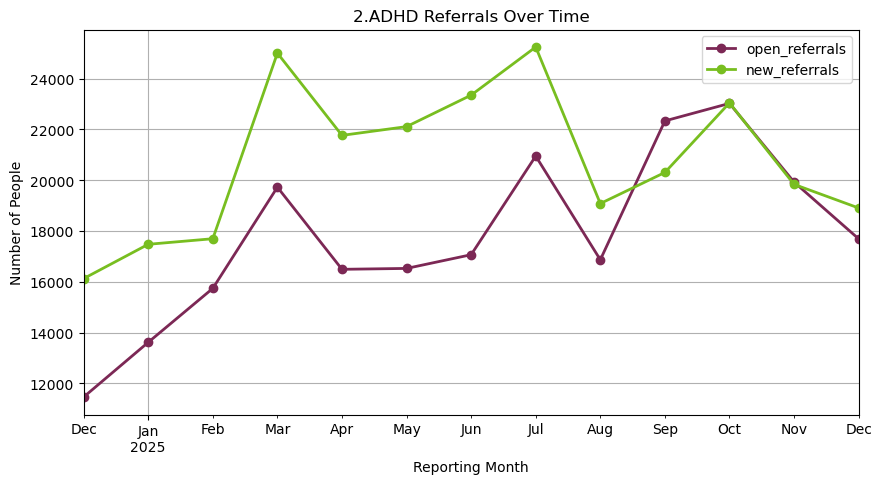

In [63]:
# Trend in referrals over time

monthly_df[['open_referrals', 'new_referrals']].plot(
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=['#7C2855', '#78BE20']
)

plt.title('2.ADHD Referrals Over Time')
plt.xlabel('Reporting Month')
plt.ylabel('Number of People')
plt.grid(True)

plt.savefig(
    "images/chart_2_referrals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


---
# ✎ Note: Chart 2 = service flow (new referrals + open referrals) ➡ Trend in ADHD Referrals

## Initial Findings

The chart shows monthly trends in both open referrals and new referrals between December 2024 and December 2025.
New referrals remained consistently higher than open referrals throughout the reporting period, suggesting that demand for ADHD services continued to exceed the number of referrals being actively managed within the system.

Both indicators increased overall during the year, although there was noticeable month-to-month variation. New referrals rose from approximately 16,000 people in December 2024 to around 19,000 people in December 2025, peaking at just over 25,000 in July 2025. Open referrals increased from around 11,500 to almost 18,000 over the same period.

The fluctuations seen across several months may reflect a combination of seasonal factors, changes in service activity, reporting coverage or local variation in referral pathways. Despite these fluctuations, the overall trend suggests sustained and growing demand for ADHD assessment and treatment services throughout 2025.


In [64]:
# Create dataset for age-group prevalence analysis

age_prevalence_df = pivot_df[
    ['reporting_period_start_date',
     'primary_level',
     'prevalence']
].copy()

# Define age order

age_order = [
    '0 to 4',
    '5 to 17',
    '18 to 24',
    '25+'
]

age_prevalence_df['primary_level'] = pd.Categorical(
    age_prevalence_df['primary_level'],
    categories=age_order,
    ordered=True
)

age_prevalence_df = age_prevalence_df.sort_values(
    ['reporting_period_start_date', 'primary_level']
)

age_prevalence_df.head(12)

indicator_id,reporting_period_start_date,primary_level,prevalence
0,2024-12-01,0 to 4,2055.0
3,2024-12-01,5 to 17,140365.0
1,2024-12-01,18 to 24,65780.0
2,2024-12-01,25+,157390.0
4,2025-01-01,0 to 4,2045.0
7,2025-01-01,5 to 17,142485.0
5,2025-01-01,18 to 24,65770.0
6,2025-01-01,25+,158240.0
8,2025-02-01,0 to 4,2075.0
11,2025-02-01,5 to 17,144845.0


In [65]:
# Validation cell

age_prevalence_df.shape

(52, 3)

---
# ✎ Age-Group Prevalence Dataset 

The prevalence dataset was reshaped into a pivot table to support age-group comparisons over time. Each row represents a reporting month and each column represents an age group.

This structure makes it easier to visualise trends in diagnosed ADHD prevalence across different age groups and identify which groups contributed most to overall growth during the reporting period.


In [66]:
# Create age-group prevalence pivot table

prevalence_by_age = age_prevalence_df.pivot(
    index='reporting_period_start_date',
    columns='primary_level',
    values='prevalence'
)

prevalence_by_age.head()

primary_level,0 to 4,5 to 17,18 to 24,25+
reporting_period_start_date,,,,
2024-12-01,2055.0,140365.0,65780.0,157390.0
2025-01-01,2045.0,142485.0,65770.0,158240.0
2025-02-01,2075.0,144845.0,85845.0,218895.0
2025-03-01,2455.0,144500.0,89190.0,231620.0
2025-04-01,2465.0,146675.0,94180.0,248185.0


In [67]:
# Validation cell

prevalence_by_age.shape

(13, 4)

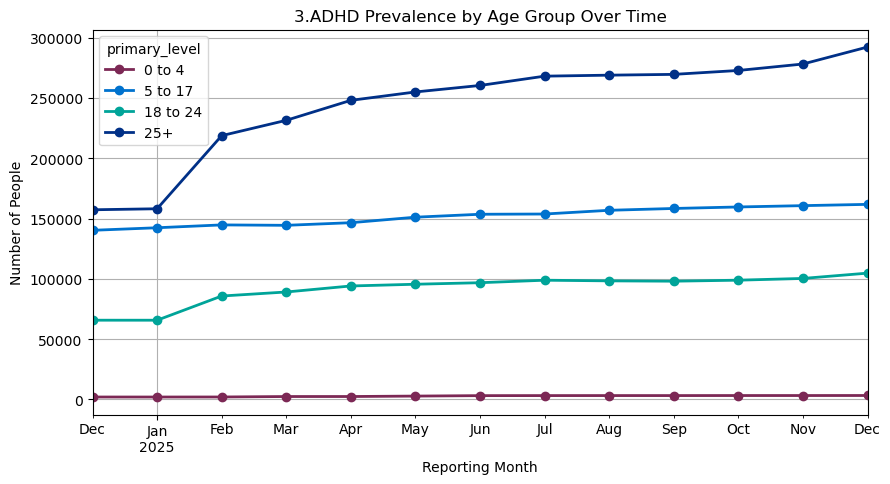

In [68]:
# ADHD prevalence by age group over time

import matplotlib.pyplot as plt

prevalence_by_age.plot(
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=[
        '#7C2855',  # 0 to 4
        '#0072CE',  # 5 to 17
        '#00A499',  # 18 to 24
        '#003087'   # 25+
    ]
)

plt.title('3.ADHD Prevalence by Age Group Over Time')
plt.xlabel('Reporting Month')
plt.ylabel('Number of People')
plt.grid(True)

plt.savefig(
    "images/chart_3_prevalence_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
### My notes:

This chart (3) shows diagnosed ADHD prevalence across the four age groups between December 2024 and December 2025.

Comparing age groups separately allows differences in growth patterns to be identified. This helps determine which groups contributed most to the overall increase in diagnosed ADHD prevalence during the reporting period.

In [69]:
# Validation cell

prevalence_by_age.shape

(13, 4)

---
# ✎ Note: Chart 3 = ADHD prevalence by age group over time  

##  Initial Findings

The chart shows diagnosed ADHD prevalence by age group between December 2024 and December 2025.

The 25+ age group had the highest prevalence throughout the reporting period and contributed most to the overall increase. Prevalence in this group increased from approximately 157,000 people in December 2024 to 293,000 people in December 2025.

The 18–24 age group also showed substantial growth, increasing from around 66,000 to 105,000 people over the same period.

In contrast, prevalence among children aged 5–17 remained relatively stable, while the 0–4 age group represented only a very small proportion of recorded cases throughout the period.

The largest increases again occurred between January and February 2025, which may partly reflect improvements in reporting coverage associated with NHS England's ADHD Data Improvement Plan, alongside increased identification and diagnosis of ADHD.

In [70]:
#Create age-group waiting list dataset 

age_waiting_df = pivot_df[
    ['reporting_period_start_date',
     'primary_level',
     'waiting_list']
].copy()

age_waiting_df.head()

indicator_id,reporting_period_start_date,primary_level,waiting_list
0,2024-12-01,0 to 4,1210.0
1,2024-12-01,18 to 24,51560.0
2,2024-12-01,25+,127850.0
3,2024-12-01,5 to 17,77825.0
4,2025-01-01,0 to 4,1190.0


In [71]:
age_waiting_df.shape

(52, 3)

In [72]:
# Create age-group waiting list pivot table

waiting_by_age = age_waiting_df.pivot(
    index='reporting_period_start_date',
    columns='primary_level',
    values='waiting_list'
)

waiting_by_age = waiting_by_age[
    ['0 to 4', '5 to 17', '18 to 24', '25+']
]
waiting_by_age.head()

primary_level,0 to 4,5 to 17,18 to 24,25+
reporting_period_start_date,,,,
2024-12-01,1210.0,77825.0,51560.0,127850.0
2025-01-01,1190.0,78380.0,51185.0,128125.0
2025-02-01,1200.0,79385.0,70820.0,188060.0
2025-03-01,1635.0,78215.0,74015.0,200315.0
2025-04-01,1655.0,79665.0,78950.0,216605.0


In [73]:
# Validation cell

waiting_by_age.shape

(13, 4)

---
# ✎ Age-Group Waiting List Dataset

The waiting list dataset was reshaped into a pivot table to support age-group comparisons over time. Each row represents a reporting month and each column represents an age group.

This structure makes it easier to identify which age groups contributed most to waiting list growth during the reporting period.

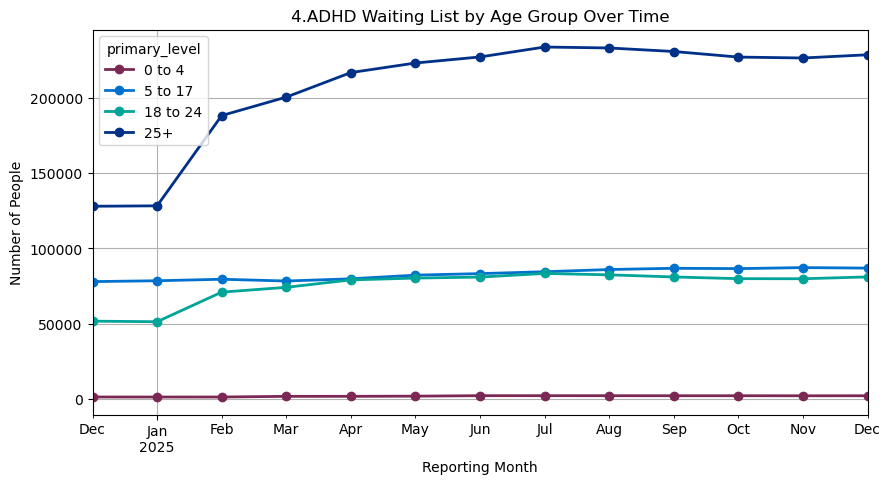

In [74]:
# ADHD waiting list by age group over time

import matplotlib.pyplot as plt

waiting_by_age.plot(
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=[
        '#7C2855',  # 0 to 4
        '#0072CE',  # 5 to 17
        '#00A499',  # 18 to 24
        '#003087'   # 25+
    ]
)

plt.title('4.ADHD Waiting List by Age Group Over Time')
plt.xlabel('Reporting Month')
plt.ylabel('Number of People')
plt.grid(True)

plt.savefig(
    "images/chart_4_waiting_list_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
# ✎ Note: Chart 4 = ADHD Waiting List by Age Group Over Time

##  Initial Findings 

The chart shows clear differences in ADHD waiting list size across age groups between December 2024 and December 2025.

The 25+ age group consistently had the largest waiting list and experienced the greatest overall growth during the reporting period. Waiting lists for adults increased substantially between January and July 2025 before beginning to stabilise.

The 5–17 and 18–24 age groups followed similar patterns, with more gradual growth throughout the year. By contrast, waiting lists for children aged 0–4 remained very small.

As with the prevalence data, the largest increase occurred between January and February 2025. This may partly reflect improvements in data coverage and reporting following NHS England's ADHD Data Improvement Plan, alongside genuine growth in demand for ADHD services.

Overall, the findings suggest that adult ADHD services are experiencing the greatest pressure, with the largest numbers of people both diagnosed with ADHD and waiting for assessment or treatment.

In [75]:
# Create age-group waiting list ratios ➡ (Which age groups appear to have the largest gap between diagnosed prevalence and waiting-list demand?)

waiting_ratio_by_age = (
    waiting_by_age / prevalence_by_age
) * 100

waiting_ratio_by_age.head()

primary_level,0 to 4,5 to 17,18 to 24,25+
reporting_period_start_date,,,,
2024-12-01,58.880779,55.444733,78.382487,81.231336
2025-01-01,58.190709,55.009299,77.824236,80.968782
2025-02-01,57.831325,54.806863,82.497525,85.913337
2025-03-01,66.598778,54.128028,82.985761,86.484328
2025-04-01,67.139959,54.313959,83.828838,87.275621


In [76]:
# Validaton cell

waiting_ratio_by_age.describe()

primary_level,0 to 4,5 to 17,18 to 24,25+
count,13.000000,13.000000,13.000000,13.000000
mean,62.477772,54.476719,81.547371,84.463807
std,2.966886,0.487331,2.533378,3.119282
min,57.831325,53.609043,77.201183,78.110627
25%,61.329305,54.128028,79.374720,81.300638
50%,62.654867,54.313959,82.497525,85.913337
75%,64.142195,54.806863,83.631376,87.068275
max,67.139959,55.444733,84.113188,87.381685


---
# ✎ Key observations ➡ age-group waiting list ratios

- The highest waiting-list-to-prevalence ratios were observed in adults aged 25+ (mean 84.5%) and young adults aged 18–24 (mean 81.5%).
- Children aged 5–17 had the lowest ratio (mean 54.5%), while the 0–4 age group averaged 62.5%.
- The ratio remained relatively stable throughout the reporting period for all age groups, suggesting a persistent difference between adult and child ADHD service demand.
- These findings indicate that waiting-list demand is proportionally much higher among adults than children, which may reflect greater unmet assessment need in adult services.
- The differences between age groups remained relatively stable throughout the reporting period. Adults consistently showed higher waiting-list-to-prevalence ratios than children, suggesting that the greater apparent gap between diagnosed prevalence and waiting-list demand in adult services was sustained across the year rather than being driven by a single reporting period.


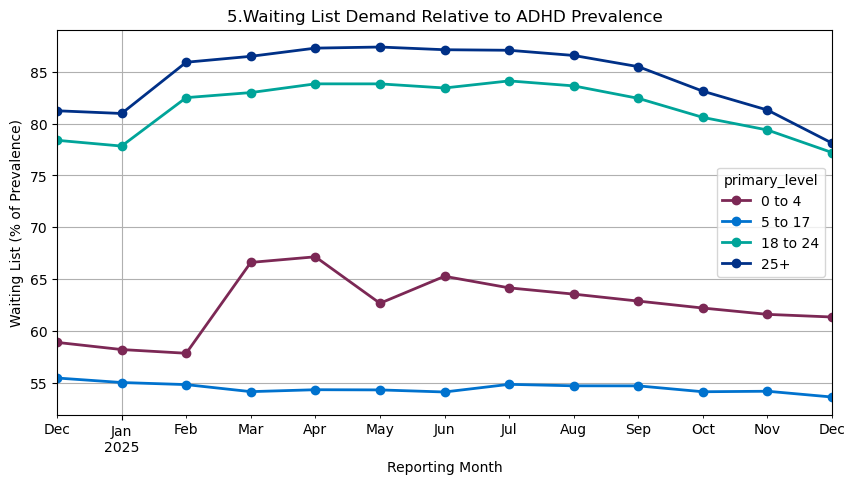

In [77]:
# Waiting list as percentage of prevalence by age group

waiting_ratio_by_age.plot(
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    color=[
        '#7C2855',  # 0 to 4
        '#0072CE',  # 5 to 17
        '#00A499',  # 18 to 24
        '#003087'   # 25+
    ]
)

plt.title('5.Waiting List Demand Relative to ADHD Prevalence')
plt.xlabel('Reporting Month')
plt.ylabel('Waiting List (% of Prevalence)')
plt.grid(True)

plt.savefig(
    "images/chart_5_waiting_list_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
# ✎ Notes: Chart 5 = Waiting List Demand Relative to ADHD Prevalence

This chart compares waiting-list demand with diagnosed ADHD prevalence across the four age groups between December 2024 and December 2025.

The highest ratios were consistently seen in the adult age groups (18–24 and 25+), where waiting-list demand remained close to or above 80% of recorded prevalence for much of the reporting period. In comparison, the 5–17 age group remained relatively stable at around 55%.

What stands out is how consistent these patterns are across the year. This suggests that the higher relative demand seen in adult services is unlikely to be the result of a single reporting period or data anomaly, and may instead reflect a sustained difference between adult and child ADHD service demand.

Towards the end of 2025 there is a small reduction in the ratios, particularly in the adult age groups. This may indicate changes in service capacity, reporting coverage or underlying demand, although further analysis would be needed to understand the reasons for this change.


In [78]:
# Average waiting-list-to-prevalence ratio by age group

average_ratio = waiting_ratio_by_age.mean().sort_values(ascending=False)

print(average_ratio)

primary_level
25+         84.463807
18 to 24    81.547371
0 to 4      62.477772
5 to 17     54.476719
dtype: float64


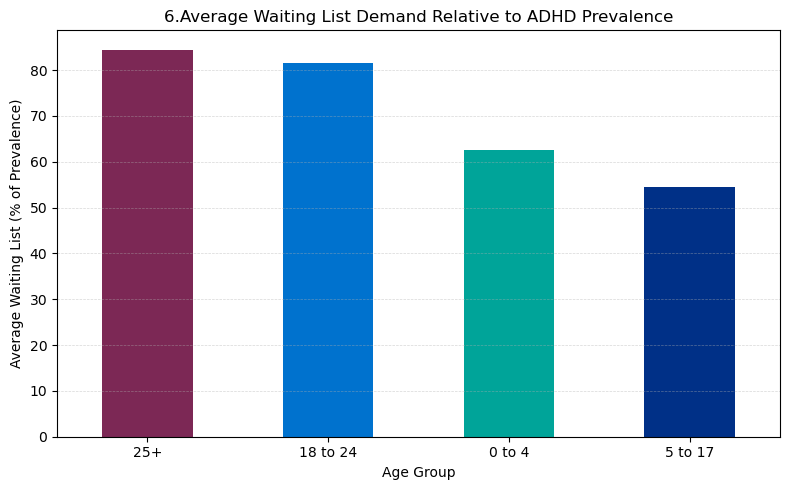

In [79]:
# Create Chart 6

average_ratio.plot(
    kind='bar',
    figsize=(8, 5),
    color=[
        '#7C2855',  # 0 to 4
        '#0072CE',  # 5 to 17
        '#00A499',  # 18 to 24
        '#003087'   # 25+
    ]
)

plt.title('6.Average Waiting List Demand Relative to ADHD Prevalence')
plt.xlabel('Age Group')
plt.ylabel('Average Waiting List (% of Prevalence)')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.5,
    alpha=0.5
)
plt.tight_layout()

plt.savefig(
    "images/chart_6_average_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ✎ Note: Chart 6 = Average Waiting List Demand Relative to ADHD Prevalence

## Findings 

a. This chart compares the average waiting-list demand relative to recorded ADHD prevalence across the four age groups between December 2024 and December 2025.

b. The highest ratios were observed in the adult age groups. On average, the waiting list represented approximately 84% of recorded prevalence in the 25+ group and 82% in the 18–24 group.

c. In comparison, the ratio was substantially lower for younger age groups, averaging around 63% for ages 0–4 and 55% for ages 5–17.

d. This suggests that demand for ADHD assessment and treatment is proportionally much higher within adult services than within children's services.

e. The differences between age groups remained remarkably consistent throughout the reporting period. The low standard deviations observed across all four groups suggest that these patterns were stable over time rather than being driven by a single reporting month or short-term fluctuation.

f. Based on this analysis, adults aged 18 and over appear to experience the greatest relative service pressure. This makes adult ADHD services a key area for further investigation when considering potential unmet assessment demand.

---
# ✎ Estimating Potential Unmet Demand

Up to this point, the analysis has focused on understanding the data and identifying patterns over time and across age groups.

The next step is to explore what these findings might tell us about potential unmet demand. The available datasets do not allow unmet need to be measured directly, but comparing prevalence and waiting-list activity can provide a useful indication of where service pressure appears to be greatest.

This section uses a simple ratio between waiting-list activity and recorded ADHD prevalence to explore these patterns further.


In [80]:
# Overall waiting-list-to-prevalence ratio

monthly_df['waiting_ratio'] = (
    monthly_df['waiting_list']
    / monthly_df['prevalence']
) * 100

monthly_df[['waiting_ratio']].head()

,waiting_ratio
reporting_period_start_date,
2024-12-01,70.692579
2025-01-01,70.244750
2025-02-01,75.159412
2025-03-01,75.717508
2025-04-01,76.677755


In [81]:
monthly_df['waiting_ratio'].describe()

count    13.000000
mean     74.452489
std       2.503545
min      70.244750
25%      72.786973
50%      75.564808
75%      76.420891
max      76.908919
Name: waiting_ratio, dtype: float64

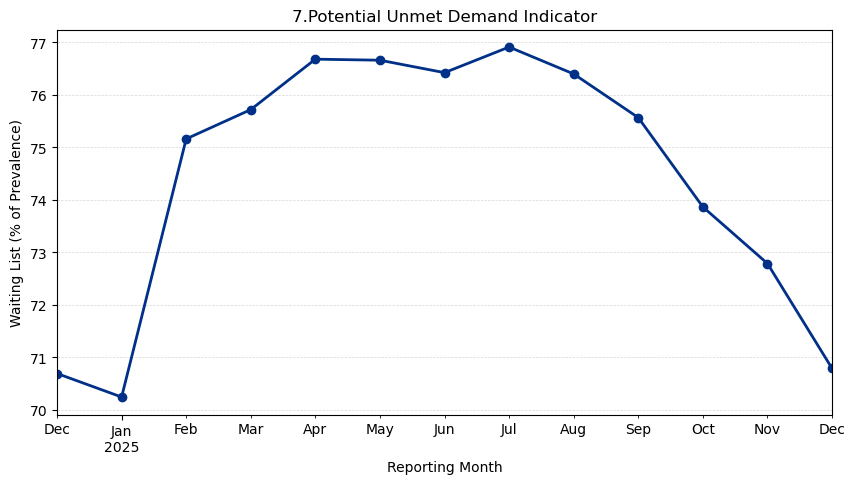

In [82]:
# Create Chart 7 

monthly_df['waiting_ratio'].plot(
    figsize=(10,5),
    marker='o',
    linewidth=2,
    color='#003087'
)

plt.title('7.Potential Unmet Demand Indicator')
plt.xlabel('Reporting Month')
plt.ylabel('Waiting List (% of Prevalence)')

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.5,
    alpha=0.5
)

plt.savefig(
    "images/chart_7_unmet_demand_indicator.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
# ✎ Note: Chart 7 = Potential Unmet Demand Indicator

## Findings

a. This chart shows the overall ratio between ADHD waiting-list activity and recorded ADHD prevalence across all age groups.

b. The ratio increased from around 70% at the start of the reporting period to approximately 77% during mid-2025, before gradually declining towards the end of the year.

c. Throughout the period, the ratio remained consistently high, suggesting that waiting-list activity represented a substantial proportion of recorded ADHD prevalence.

d. While this should not be interpreted as a direct measure of unmet need, it provides a useful indication of service pressure and the relationship between demand and access to assessment or treatment.

e. The relatively stable pattern observed across the year suggests that the relationship between prevalence and waiting-list activity was broadly consistent rather than being driven by a single reporting month.

f. Combined with the earlier age-group analysis, these findings suggest that service pressure may be concentrated within adult ADHD pathways.


---
# ✎ Key Findings Summary

1. Finding 1: ADHD prevalence increased substantially during 2025.
2. Finding 2: Waiting lists also increased but growth slowed later in the year.
3. Finding 3: Adult age groups accounted for most prevalence growth.
4. Finding 4: Adult age groups showed the highest waiting-list-to-prevalence ratios.
5. Finding 5: The pattern remained stable across the reporting period.
6. Finding 6: Adults aged 18+ appear to experience the greatest relative service pressure.

In [83]:
# Create summary statistics for key indicators

summary_df = pd.DataFrame({
    'Start Value': monthly_df.iloc[0],
    'End Value': monthly_df.iloc[-1]
})

summary_df['Absolute Change'] = (
    summary_df['End Value']
    - summary_df['Start Value']
)

summary_df['% Change'] = (
    summary_df['Absolute Change']
    / summary_df['Start Value']
) * 100

summary_df.round(2)

,Start Value,End Value,Absolute Change,% Change
prevalence,365590.00,562450.00,196860.0,53.85
waiting_list,258445.00,398160.00,139715.0,54.06
open_referrals,11460.00,17690.00,6230.0,54.36
new_referrals,16125.00,18905.00,2780.0,17.24
waiting_ratio,70.69,70.79,0.1,0.14


In [84]:
# Validation cell
summary_df

,Start Value,End Value,Absolute Change,% Change
prevalence,365590.000000,562450.000000,196860.000000,53.847206
waiting_list,258445.000000,398160.000000,139715.000000,54.059858
open_referrals,11460.000000,17690.000000,6230.000000,54.363002
new_referrals,16125.000000,18905.000000,2780.000000,17.240310
waiting_ratio,70.692579,70.790292,0.097713,0.138223


---
# ✎  Key Findings Summary

This table summarises the change observed across the main ADHD indicators during the reporting period. It provides a concise overview of how prevalence, waiting lists and referral activity changed between December 2024 and December 2025.

**Key**
1. Prevalence, waiting lists and open referrals all grew at almost exactly the same rate.
- Prevalence: +53.8%
- Waiting list: +54.1%
- Open referrals: +54.4%

Those numbers are remarkably close.

2. New referrals did not grow at the same rate. New referrals only increased by around 17%. That suggests the large increases seen elsewhere are unlikely to be explained simply by more people entering services during 2025.
   
3. The overall waiting-list ratio barely changed.
- 70.69% → 70.79%
- Change = 0.14%

That supports the finding from Chart 7 that the relationship between prevalence and waiting-list demand remained relatively stable throughout the year.


---
# ✎  Overall Conclusions

This analysis explored ADHD prevalence, waiting-list activity and referral patterns in England between December 2024 and December 2025 using data from the NHS Neurodevelopmental Data Hub.

The findings suggest that both ADHD prevalence and waiting-list demand increased substantially during the reporting period. Adult age groups consistently showed higher waiting-list demand relative to recorded prevalence than younger age groups.

The ratio between waiting-list activity and prevalence remained relatively stable across the year, suggesting that service pressure was sustained rather than driven by a single reporting period.

While the available data cannot directly measure unmet need, the findings suggest that adult ADHD services may experience greater relative pressure and could represent an important area for further investigation.

---
# ✎  Limitations 

a. The analysis uses aggregate national data and does not include individual patient records.

b. The waiting-list-to-prevalence ratio is used as an indicator of potential unmet demand and should not be interpreted as a direct measure of unmet need.

c. Changes observed during early 2025 may partly reflect improvements in reporting coverage associated with NHS England's ADHD Data Improvement Plan.

d. The analysis covers a relatively short reporting period of thirteen months.

e. Regional variation could not be explored within the scope of this project.

---
# ✎ Recommendations

Based on the findings from this analysis, four recommendations are proposed:

### 1. Continue improving ADHD data quality and reporting coverage

Continued improvements in data completeness and consistency would support more accurate monitoring of ADHD demand and service activity.

### 2. Undertake further investigation into adult ADHD service demand

Adult age groups consistently showed higher waiting-list demand relative to recorded prevalence. Future work could explore referral-to-treatment times, provider capacity, diagnostic throughput and Right to Choose activity.

### 3. Develop more robust measures of unmet demand

Future analyses could combine prevalence data, referral activity, service capacity information and diagnostic throughput to develop more sophisticated indicators of unmet demand.

### 4. Explore demographic differences in ADHD service demand and access

Future work could examine variation by ethnicity, sex, deprivation and geography to better understand potential inequalities in access to assessment and treatment.
